In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
DATA_DIR = '../data/'

df = pd.read_csv(f'{DATA_DIR}/raw/OnlineRetail.csv')

In [6]:
df.head(5)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,quantity,unitprice,customerid
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [8]:
print("=== DATA QUALITY ASSESSMENT ===")

print("\n--- 1. Missing Values ---")
null_counts = df.isnull().sum()
null_percentages = (df.isnull().mean() * 100).round(2)

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage (%)': null_percentages
})

print(null_summary)

customerid_missing = null_summary.loc['customerid', 'Null Count']
description_missing = null_summary.loc['description', 'Null Count']
print(f"\nMissing Customer IDs: {customerid_missing:,}")
print(f"Missing Descriptions: {description_missing:,}")

=== DATA QUALITY ASSESSMENT ===

--- 1. Missing Values ---
             Null Count  Null Percentage (%)
invoiceno             0                 0.00
stockcode             0                 0.00
description        1454                 0.27
quantity              0                 0.00
invoicedate           0                 0.00
unitprice             0                 0.00
customerid       135080                24.93
country               0                 0.00

Missing Customer IDs: 135,080
Missing Descriptions: 1,454


In [9]:
print("\n--- 2. Duplicate Rows ---")

subset_cols = ['invoiceno', 'stockcode', 'quantity', 'customerid']
duplicate_mask = df.duplicated(subset=subset_cols, keep=False)
duplicate_count = df.duplicated(subset=subset_cols).sum()

print(f"Total duplicate rows found (based on InvoiceNo, StockCode, Quantity, CustomerID): {duplicate_count:,}")


--- 2. Duplicate Rows ---
Total duplicate rows found (based on InvoiceNo, StockCode, Quantity, CustomerID): 5,431


In [10]:
duplicated_rows_df = df[duplicate_mask].sort_values(by=subset_cols)
duplicated_rows_df.head(20)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [11]:
original_rows = len(df)

df.drop_duplicates(subset=subset_cols, keep='first', inplace=True)

new_rows = len(df)

duplicate_rows_dropped = original_rows - new_rows
print(f'Total number of duplcate roows droopped:{duplicate_rows_dropped}')

Total number of duplcate roows droopped:5431


In [12]:
print("\n--- 3. InvoiceDate Range ---")

df['invoicedate'] = pd.to_datetime(df['invoicedate'])

first_date = df['invoicedate'].min()
last_date = df['invoicedate'].max()
date_span = last_date - first_date

print(f"First Invoice Date: {first_date}")
print(f"Last Invoice Date:  {last_date}")
print(f"Total Date Span:    {date_span.days} days")


--- 3. InvoiceDate Range ---
First Invoice Date: 2010-12-01 08:26:00
Last Invoice Date:  2011-12-09 12:50:00
Total Date Span:    373 days


In [13]:
print("\n--- 4. Cancelled Orders Count ---")

cancelled_mask = df['invoiceno'].str.startswith('C', na=False)

cancelled_count = cancelled_mask.sum()
total_rows = len(df)
cancelled_pct = (cancelled_count / total_rows) * 100

print(f"Total cancelled transactions found: {cancelled_count:,}")
print(f"Percentage of dataset: {cancelled_pct:.2f}%")

cancelled_df = df[cancelled_mask]


--- 4. Cancelled Orders Count ---
Total cancelled transactions found: 9,177
Percentage of dataset: 1.71%


In [14]:
print("\n--- 5. Validating Negative Quantities ---")

negative_qty_cancellations = (cancelled_df['quantity'] < 0).sum()

print(f"Cancelled rows with negative quantity: {negative_qty_cancellations:,} out of {cancelled_count:,}")

if negative_qty_cancellations == cancelled_count:
    print("Validation passed: All 'C' invoices have negative quantities.")
else:
    print("WARNING: Some 'C' invoices have positive quantities. Further investigation needed.")


--- 5. Validating Negative Quantities ---
Cancelled rows with negative quantity: 9,177 out of 9,177
Validation passed: All 'C' invoices have negative quantities.


In [15]:
print("\n--- 6. Removing Cancelled Orders ---")
# Keep only the rows where the mask is False (using the ~ operator)
df_clean = df[~cancelled_mask].copy()

print(f"Original row count: {total_rows:,}")
print(f"Cleaned row count (without cancellations): {len(df_clean):,}")
print("Cancelled orders successfully removed from the main dataframe ('df_clean').")


--- 6. Removing Cancelled Orders ---
Original row count: 536,478
Cleaned row count (without cancellations): 527,301
Cancelled orders successfully removed from the main dataframe ('df_clean').


In [16]:
print("\n--- 7. Flagging Anomalies ---")
# Find rows where quantity or price is <= 0
bad_quantity_mask = df_clean['quantity'] <= 0
bad_price_mask = df_clean['unitprice'] <= 0

bad_qty_count = bad_quantity_mask.sum()
bad_price_count = bad_price_mask.sum()

print(f"Rows with Quantity <= 0 (non-cancellations): {bad_qty_count:,}")
print(f"Rows with UnitPrice <= 0: {bad_price_count:,}")


--- 7. Flagging Anomalies ---
Rows with Quantity <= 0 (non-cancellations): 1,336
Rows with UnitPrice <= 0: 2,511


In [17]:
df_clean[bad_price_mask].sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
323389,565296,84929,code mix up? 84930,-967,2011-09-02 12:04:00,0.0,NaN,United Kingdom
51758,540674,22837,Found,26,2011-01-10 16:05:00,0.0,NaN,United Kingdom
472945,576777,22121,NaN,4,2011-11-16 13:23:00,0.0,NaN,United Kingdom
146602,549002,21278,NaN,17,2011-04-05 14:36:00,0.0,NaN,United Kingdom
41501,539856,21912,VINTAGE SNAKES & LADDERS,1,2010-12-22 14:41:00,0.0,NaN,United Kingdom
136885,548001,22451,NaN,11,2011-03-29 10:26:00,0.0,NaN,United Kingdom
320589,565049,21907,NaN,-77,2011-08-31 17:09:00,0.0,NaN,United Kingdom
142631,548620,84313B,Damaged,-32,2011-04-01 11:53:00,0.0,NaN,United Kingdom
41494,539856,22367,CHILDRENS APRON SPACEBOY DESIGN,2,2010-12-22 14:41:00,0.0,NaN,United Kingdom
210961,555332,84801A,wet damaged,-48,2011-06-02 11:11:00,0.0,NaN,United Kingdom


In [18]:
df_clean[bad_quantity_mask].sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
82794,543257,84611B,thrown away,-1430,2011-02-04 16:06:00,0.0,NaN,United Kingdom
416748,572557,22427,damages,-29,2011-10-24 17:44:00,0.0,NaN,United Kingdom
495850,578327,72807A,wet pallet,-504,2011-11-23 17:55:00,0.0,NaN,United Kingdom
436593,574171,21818,check,-130,2011-11-03 11:45:00,0.0,NaN,United Kingdom
172881,551582,84857A,NaN,-5,2011-05-03 11:21:00,0.0,NaN,United Kingdom
166266,550908,20827,damages,-68,2011-04-21 12:39:00,0.0,NaN,United Kingdom
431379,573594,79323P,"Unsaleable, destroyed.",-2003,2011-10-31 15:16:00,0.0,NaN,United Kingdom
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
281551,561536,84927E,NaN,-2,2011-07-28 09:58:00,0.0,NaN,United Kingdom
178016,552222,21974,NaN,-45,2011-05-06 15:22:00,0.0,NaN,United Kingdom


In [19]:
print("--- 8. Removing Anomalies ---")
# Keep only rows where BOTH quantity and unitprice are strictly positive
df_final = df_clean[(df_clean['quantity'] > 0) & (df_clean['unitprice'] > 0)].copy()

rows_removed = len(df_clean) - len(df_final)
print(f"Total anomalous rows removed: {rows_removed:,}")
print(f"Cleaned dataset ready for analysis: {len(df_final):,} rows")

--- 8. Removing Anomalies ---
Total anomalous rows removed: 2,511
Cleaned dataset ready for analysis: 524,790 rows


In [20]:
print("--- 9. Distribution Checks ---")

dist_summary = df_final[['quantity', 'unitprice']].describe().round(2)
print(dist_summary)

print("\nTop 5 Highest Quantities:")
print(df_final[['invoiceno', 'description', 'stockcode', 'quantity']].sort_values(by='quantity', ascending=False).head(5))

print("\nTop 5 Highest Unit Prices:")
print(df_final[['invoiceno', 'description', 'stockcode', 'unitprice']].sort_values(by='unitprice', ascending=False).head(5))

--- 9. Distribution Checks ---
        quantity  unitprice
count  524790.00  524790.00
mean       10.62       3.91
std       156.29      35.73
min         1.00       0.00
25%         1.00       1.25
50%         4.00       2.08
75%        11.00       4.13
max     80995.00   13541.33

Top 5 Highest Quantities:
       invoiceno                        description stockcode  quantity
540421    581483        PAPER CRAFT , LITTLE BIRDIE     23843     80995
61619     541431     MEDIUM CERAMIC TOP STORAGE JAR     23166     74215
421632    573008  WORLD WAR 2 GLIDERS ASSTD DESIGNS     84077      4800
206121    554868               SMALL POPCORN HOLDER     22197      4300
97432     544612              EMPIRE DESIGN ROSETTE     22053      3906

Top 5 Highest Unit Prices:
       invoiceno      description  stockcode  unitprice
15017     537632       AMAZON FEE  AMAZONFEE   13541.33
299982   A563185  Adjust bad debt          B   11062.06
173382    551697          POSTAGE       POST    8142.75
297723

In [21]:
# Look at the massive quantities (e.g., top 10 largest orders)
print("--- Inspecting Extreme Quantities ---")
extreme_qty = df_final[df_final['quantity'] > 5000].sort_values('quantity', ascending=False)
# If you have a 'description' or 'stockcode' column, make sure to include it here!
print(extreme_qty[['invoiceno', 'stockcode', 'description', 'quantity', 'unitprice']].head(10))

# Look at the massive prices (e.g., anything over $1,000)
print("\n--- Inspecting Extreme Prices ---")
extreme_price = df_final[df_final['unitprice'] > 1000].sort_values('unitprice', ascending=False)
print(extreme_price[['invoiceno', 'stockcode', 'description', 'quantity', 'unitprice']].head(30))

--- Inspecting Extreme Quantities ---
       invoiceno stockcode                     description  quantity  \
540421    581483     23843     PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   

        unitprice  
540421       2.08  
61619        1.04  

--- Inspecting Extreme Prices ---
       invoiceno  stockcode      description  quantity  unitprice
15017     537632  AMAZONFEE       AMAZON FEE         1   13541.33
299982   A563185          B  Adjust bad debt         1   11062.06
173382    551697       POST          POSTAGE         1    8142.75
297723    562955        DOT   DOTCOM POSTAGE         1    4505.17
268028    560373          M           Manual         1    4287.63
422351    573077          M           Manual         1    4161.06
422376    573080          M           Manual         1    4161.06
406406    571751          M           Manual         1    3949.32
374542    569382          M           Manual         1  

In [22]:
import pandas as pd

# Assuming you are continuing with 'df_cust' (or 'df_final' if you didn't drop missing customers)

print("=== SEGMENTING ADMIN CODES VS RETAIL PRODUCTS ===")

# ---------------------------------------------------------
# 1. Define the Administrative Codes
# ---------------------------------------------------------
# Based on your inspection (and common codes in similar retail datasets)
admin_codes = ['AMAZONFEE', 'B', 'POST', 'DOT', 'M', 'BANK CHARGES', 'CRUK', 'PADS']

# Ensure stockcode is a string and uppercase for safe matching
df_final['stockcode'] = df_final['stockcode'].astype(str).str.upper()

# ---------------------------------------------------------
# 2. Split the Dataset
# ---------------------------------------------------------
# Create a mask for rows where the stockcode is in our admin list
admin_mask = df_final['stockcode'].isin(admin_codes)

# Dataframe 1: Pure Retail Products (The mask is False)
df_retail = df_final[~admin_mask].copy()

# Dataframe 2: Administrative / Financial Entries (The mask is True)
df_admin = df_final[admin_mask].copy()

# ---------------------------------------------------------
# 3. Validate the Split
# ---------------------------------------------------------
print("\n--- Split Results ---")
print(f"Total original rows: {len(df_final):,}")
print(f"Retail Product rows: {len(df_retail):,} ({(len(df_retail)/len(df_final))*100:.1f}%)")
print(f"Admin/Fee rows:      {len(df_admin):,} ({(len(df_admin)/len(df_final))*100:.1f}%)")

print("\n--- Top 5 Highest Prices in RETAIL Data Now ---")
print(df_retail[['invoiceno', 'stockcode', 'description', 'unitprice']].sort_values('unitprice', ascending=False).head())

=== SEGMENTING ADMIN CODES VS RETAIL PRODUCTS ===

--- Split Results ---
Total original rows: 524,790
Retail Product rows: 522,642 (99.6%)
Admin/Fee rows:      2,148 (0.4%)

--- Top 5 Highest Prices in RETAIL Data Now ---
       invoiceno stockcode                     description  unitprice
222682    556446     22502  PICNIC BASKET WICKER 60 PIECES      649.5
222680    556444     22502  PICNIC BASKET WICKER 60 PIECES      649.5
82768     543253     22655     VINTAGE RED KITCHEN CABINET      295.0
171178    551393     22656    VINTAGE BLUE KITCHEN CABINET      295.0
133994    547814     22656    VINTAGE BLUE KITCHEN CABINET      295.0


In [23]:
print("\n--- 10. Creating Total Price Column ---")

df_final['total_price'] = df_final['quantity'] * df_final['unitprice']

print("Created 'total_price' column successfully.")

print(df_final[['quantity', 'unitprice', 'total_price']].head())


--- 10. Creating Total Price Column ---
Created 'total_price' column successfully.
   quantity  unitprice  total_price
0         6       2.55        15.30
1         6       3.39        20.34
2         8       2.75        22.00
3         6       3.39        20.34
4         6       3.39        20.34


In [24]:
df_cust = df_final.dropna(subset=['customerid']).copy()

print("\n--- 1. Unique Customers ---")
unique_customers = df_cust['customerid'].nunique()
print(f"Total unique customers: {unique_customers:,}")


--- 1. Unique Customers ---
Total unique customers: 4,338


In [25]:
print("\n--- 2. Orders per Customer Distribution ---")
# Count unique invoices (orders) per customer
orders_per_cust = df_cust.groupby('customerid')['invoiceno'].nunique()

print("Descriptive statistics for orders per customer:")
print(orders_per_cust.describe().round(2))

# Quick validation check for skewness
median_orders = orders_per_cust.median()
mean_orders = orders_per_cust.mean()
print(f"\nMedian orders: {median_orders}")
print(f"Mean orders: {mean_orders:.2f}")
if mean_orders > (median_orders * 1.5):
    print("-> Result: Highly right-skewed distribution confirmed.")


--- 2. Orders per Customer Distribution ---
Descriptive statistics for orders per customer:
count    4338.00
mean        4.27
std         7.70
min         1.00
25%         1.00
50%         2.00
75%         5.00
max       209.00
Name: invoiceno, dtype: float64

Median orders: 2.0
Mean orders: 4.27
-> Result: Highly right-skewed distribution confirmed.


In [26]:
print("\n--- 3. Top 10 Customers by Revenue ---")
# Group by customer and sum their total spend, then sort descending
revenue_per_cust = df_cust.groupby('customerid')['total_price'].sum().sort_values(ascending=False)

# Display the top 10
print(revenue_per_cust.head(10).reset_index().rename(columns={'total_price': 'total_revenue'}))


--- 3. Top 10 Customers by Revenue ---
   customerid  total_revenue
0     14646.0      280206.02
1     18102.0      259657.30
2     17450.0      194390.79
3     16446.0      168472.50
4     14911.0      143711.17
5     12415.0      124914.53
6     14156.0      117210.08
7     17511.0       91062.38
8     16029.0       80613.24
9     12346.0       77183.60


In [27]:
print("\n--- 4. Pareto Principle Check (80/20 Rule) ---")
total_revenue = revenue_per_cust.sum()

# Calculate how many customers make up the top 20%
top_20_percent_count = int(unique_customers * 0.20)

# Sum the revenue of only those top 20% customers
top_20_revenue = revenue_per_cust.head(top_20_percent_count).sum()

# Calculate the percentage
pareto_percentage = (top_20_revenue / total_revenue) * 100

print(f"Total Revenue (from known customers): ${total_revenue:,.2f}")
print(f"Revenue from Top 20% ({top_20_percent_count:,} customers): ${top_20_revenue:,.2f}")
print(f"Percentage of total revenue from top 20%: **{pareto_percentage:.2f}%**")


--- 4. Pareto Principle Check (80/20 Rule) ---
Total Revenue (from known customers): $8,878,543.50
Revenue from Top 20% (867 customers): $6,626,618.84
Percentage of total revenue from top 20%: **74.64%**


In [28]:
df_cust['description'] = df_cust['description'].astype(str).str.upper().str.strip()
df_cust['stockcode'] = df_cust['stockcode'].astype(str).str.upper().str.strip()


In [29]:
print("\n--- 1. Filtering Admin/Service Codes ---")

pure_alpha_mask = df_cust['stockcode'].str.isalpha()

admin_codes_found = df_cust[pure_alpha_mask]['stockcode'].unique()
print(f"Non-product codes identified and removed: {admin_codes_found}")

# Create our pure product dataframe
df_products = df_cust[~pure_alpha_mask].copy()


--- 1. Filtering Admin/Service Codes ---
Non-product codes identified and removed: ['POST' 'M' 'PADS' 'DOT']


In [30]:
print("\n--- 2. Unique Products ---")
unique_stockcodes = df_products['stockcode'].nunique()
unique_descriptions = df_products['description'].nunique()

print(f"Unique Stock Codes: {unique_stockcodes:,}")
print(f"Unique Descriptions: {unique_descriptions:,}")

if unique_stockcodes != unique_descriptions:
    print("-> Note: There is a mismatch. This means some Stock Codes have multiple descriptions over time.")


--- 2. Unique Products ---
Unique Stock Codes: 3,661
Unique Descriptions: 3,862
-> Note: There is a mismatch. This means some Stock Codes have multiple descriptions over time.


In [31]:
# ---------------------------------------------------------
# 3. Top 20 Best-Selling Products (by Quantity)
# ---------------------------------------------------------
print("\n--- 3. Top 20 Products by Quantity ---")
# Grouping by both code and description to see the actual product name
top_by_qty = df_products.groupby(['stockcode', 'description'])['quantity'].sum().reset_index()
top_by_qty = top_by_qty.sort_values(by='quantity', ascending=False)

print(top_by_qty.head(20).to_string(index=False))


# ---------------------------------------------------------
# 4. Top 20 Best-Selling Products (by Revenue)
# ---------------------------------------------------------
print("\n--- 4. Top 20 Products by Revenue ---")
top_by_rev = df_products.groupby(['stockcode', 'description'])['total_price'].sum().reset_index()
top_by_rev = top_by_rev.sort_values(by='total_price', ascending=False)

# Formatting the revenue for better readability
top_by_rev['total_price'] = top_by_rev['total_price'].apply(lambda x: f"${x:,.2f}")
print(top_by_rev.head(20).to_string(index=False))


--- 3. Top 20 Products by Quantity ---
stockcode                        description  quantity
    23843        PAPER CRAFT , LITTLE BIRDIE     80995
    23166     MEDIUM CERAMIC TOP STORAGE JAR     77916
    84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
   85099B            JUMBO BAG RED RETROSPOT     46078
   85123A WHITE HANGING HEART T-LIGHT HOLDER     36706
    84879      ASSORTED COLOUR BIRD ORNAMENT     35263
    21212    PACK OF 72 RETROSPOT CAKE CASES     33670
    22197                     POPCORN HOLDER     30919
    23084                 RABBIT NIGHT LIGHT     27153
    22492             MINI PAINT SET VINTAGE     26076
    22616          PACK OF 12 LONDON TISSUES     25329
    21977 PACK OF 60 PINK PAISLEY CAKE CASES     24230
    17003                 BROCADE RING PURSE     22927
    22178    VICTORIAN GLASS HANGING T-LIGHT     22404
    15036          ASSORTED COLOURS SILK FAN     21876
    21915              RED  HARMONICA IN BOX     20945
    22386            JUMB

In [32]:
df_products['country'] = df_products['country'].astype(str).str.strip()

print("=== COUNTRY & GEOGRAPHIC ANALYSIS ===")

# ---------------------------------------------------------
# 1. Unique Countries
# ---------------------------------------------------------
print("\n--- 1. Geographic Footprint ---")
unique_countries = df_products['country'].nunique()
print(f"Total unique countries represented: {unique_countries}")


# ---------------------------------------------------------
# 2. Revenue and Order Volume by Country
# ---------------------------------------------------------
print("\n--- 2. Top 10 Countries by Revenue ---")
# Aggregate revenue and unique orders per country
country_stats = df_products.groupby('country').agg(
    total_revenue=('total_price', 'sum'),
    total_orders=('invoiceno', 'nunique')
).reset_index()

# Sort by revenue descending
country_stats = country_stats.sort_values(by='total_revenue', ascending=False)

# Format revenue for clean printing
country_stats_display = country_stats.copy()
country_stats_display['total_revenue'] = country_stats_display['total_revenue'].apply(lambda x: f"${x:,.2f}")

print(country_stats_display.head(10).to_string(index=False))


# ---------------------------------------------------------
# 3. UK vs. International Split (%)
# ---------------------------------------------------------
print("\n--- 3. Domestic vs. International Split ---")
# Using total orders to calculate the split
total_orders_global = country_stats['total_orders'].sum()
uk_orders = country_stats.loc[country_stats['country'] == 'United Kingdom', 'total_orders'].sum()
intl_orders = total_orders_global - uk_orders

uk_pct = (uk_orders / total_orders_global) * 100
intl_pct = (intl_orders / total_orders_global) * 100

print(f"Total Global Orders: {total_orders_global:,}")
print(f"UK Orders: {uk_orders:,} ({uk_pct:.2f}%)")
print(f"International Orders: {intl_orders:,} ({intl_pct:.2f}%)")


# ---------------------------------------------------------
# 4. DECISION: Isolate UK Data (Optional but Recommended)
# ---------------------------------------------------------
print("\n--- 4. Data Segmentation Decision ---")
# DOCUMENTATION NOTE: 
# Since ~90% of transactions are domestic, international orders often represent 
# a different business model (e.g., bulk wholesale) with different shipping 
# logistics and buying frequencies. We will isolate the UK data for standard 
# customer behavioral analysis.

df_uk = df_products[df_products['country'] == 'United Kingdom'].copy()
df_intl = df_products[df_products['country'] != 'United Kingdom'].copy()

print(f"Created 'df_uk' with {len(df_uk):,} rows for domestic analysis.")
print(f"Created 'df_intl' with {len(df_intl):,} rows for international analysis.")

=== COUNTRY & GEOGRAPHIC ANALYSIS ===

--- 1. Geographic Footprint ---
Total unique countries represented: 37

--- 2. Top 10 Countries by Revenue ---
       country total_revenue  total_orders
United Kingdom $7,243,692.89         16590
   Netherlands   $283,889.34            93
          EIRE   $261,888.12           258
       Germany   $205,381.15           443
        France   $183,987.94           380
     Australia   $138,103.81            56
         Spain    $55,706.56            88
   Switzerland    $52,441.95            47
         Japan    $37,416.37            19
       Belgium    $36,927.34            98

--- 3. Domestic vs. International Split ---
Total Global Orders: 18,416
UK Orders: 16,590 (90.08%)
International Orders: 1,826 (9.92%)

--- 4. Data Segmentation Decision ---
Created 'df_uk' with 348,907 rows for domestic analysis.
Created 'df_intl' with 42,381 rows for international analysis.


=== TIME-BASED ANALYSIS ===

--- 1. Monthly Trends (Seasonality) ---
   year_month  total_orders  total_revenue
0     2010-12          1288      495996.57
1     2011-01           872      440781.93
2     2011-02           893      354513.56
3     2011-03          1175      465487.12
4     2011-04          1055      406069.55
5     2011-05          1401      541817.24
6     2011-06          1248      523002.46
7     2011-07          1193      483273.10
8     2011-08          1126      494084.25
9     2011-09          1558      789602.14
10    2011-10          1694      812144.46
11    2011-11          2381      967576.05

--- 2. Day of Week Patterns ---
  day_of_week  total_orders
0      Monday        2543.0
1     Tuesday        2874.0
2   Wednesday        3083.0
3    Thursday        3585.0
4      Friday        2468.0
5    Saturday           NaN
6      Sunday        2037.0

--- 3. Peak Ordering Hours ---
   hour  total_orders
6    12          2860
7    13          2377
5    11          

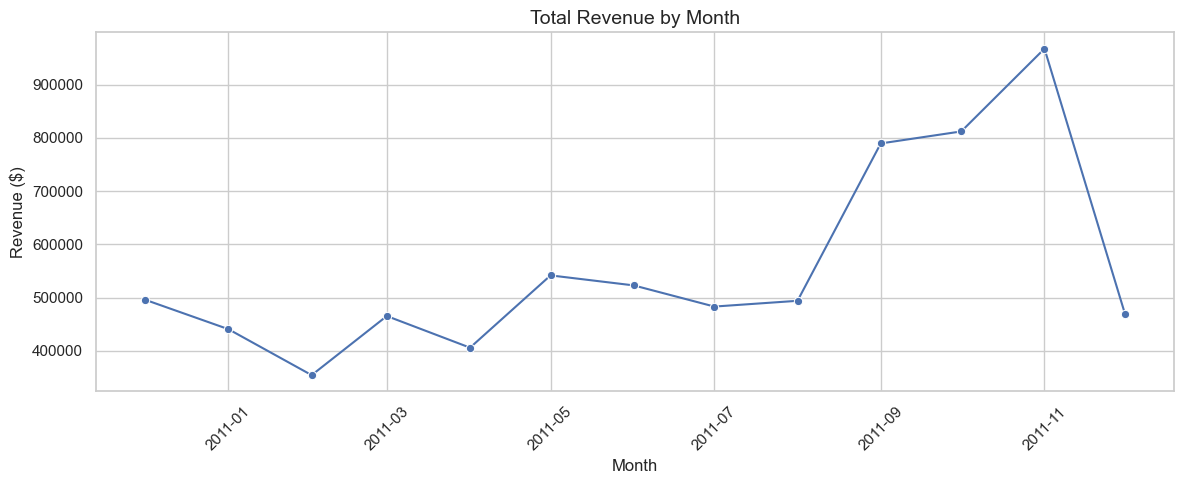

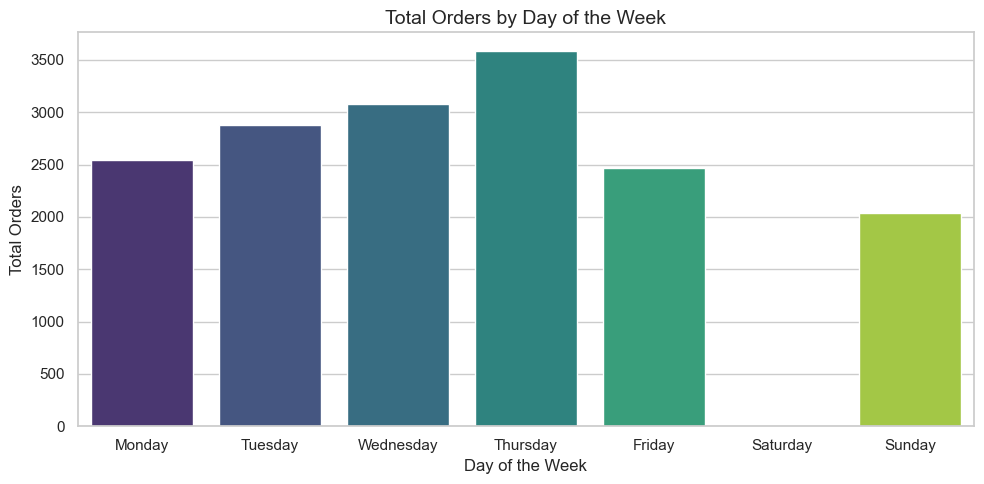

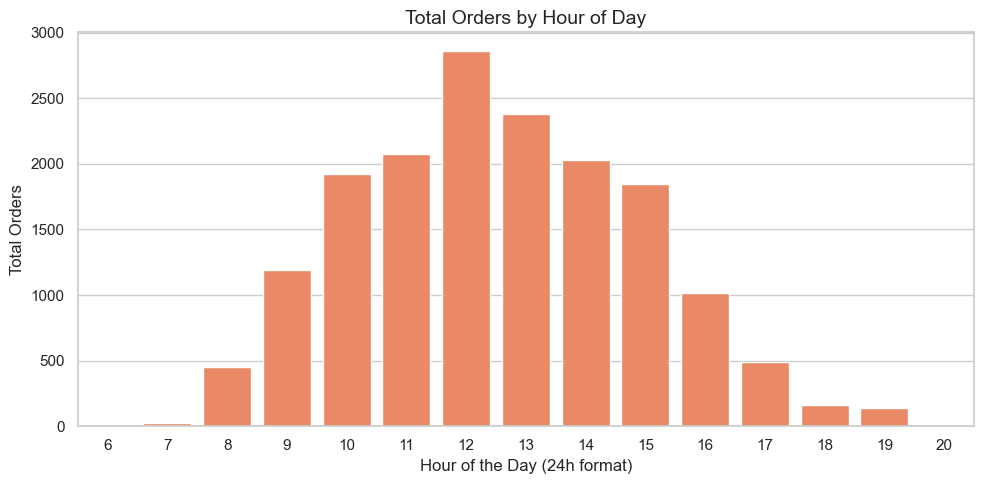

In [33]:
df_uk['invoicedate'] = pd.to_datetime(df_uk['invoicedate'])

# Extract the necessary time components for our analysis
df_uk['year_month'] = df_uk['invoicedate'].dt.to_period('M')
df_uk['day_of_week'] = df_uk['invoicedate'].dt.day_name()
df_uk['hour'] = df_uk['invoicedate'].dt.hour

# Set a clean visual style for our plots
sns.set_theme(style="whitegrid")

print("=== TIME-BASED ANALYSIS ===")

# ---------------------------------------------------------
# 1. Orders and Revenue Over Time (Monthly Trends)
# ---------------------------------------------------------
print("\n--- 1. Monthly Trends (Seasonality) ---")
# Group by Month to get unique orders and total revenue
monthly_trend = df_uk.groupby('year_month').agg(
    total_orders=('invoiceno', 'nunique'),
    total_revenue=('total_price', 'sum')
).reset_index()

# Convert year_month back to timestamp just for plotting purposes
monthly_trend['month_start'] = monthly_trend['year_month'].dt.to_timestamp()

print(monthly_trend[['year_month', 'total_orders', 'total_revenue']].head(12))

# Plotting the Monthly Revenue Trend
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trend, x='month_start', y='total_revenue', marker='o', color='b')
plt.title('Total Revenue by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png')
# plt.show() # Uncomment in your notebook to display


# ---------------------------------------------------------
# 2. Day of Week Patterns
# ---------------------------------------------------------
print("\n--- 2. Day of Week Patterns ---")
# Define the order of days to prevent alphabetical sorting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_trend = df_uk.groupby('day_of_week').agg(
    total_orders=('invoiceno', 'nunique')
).reindex(days_order).reset_index()

print(dow_trend)

# Plotting Day of Week
plt.figure(figsize=(10, 5))
sns.barplot(data=dow_trend, x='day_of_week', y='total_orders', palette='viridis')
plt.title('Total Orders by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.savefig('day_of_week_trend.png')
# plt.show()


# ---------------------------------------------------------
# 3. Hour of Day Patterns
# ---------------------------------------------------------
print("\n--- 3. Peak Ordering Hours ---")
hour_trend = df_uk.groupby('hour').agg(
    total_orders=('invoiceno', 'nunique')
).reset_index()

print(hour_trend.sort_values('total_orders', ascending=False).head(5))

# Plotting Hour of Day
plt.figure(figsize=(10, 5))
sns.barplot(data=hour_trend, x='hour', y='total_orders', color='coral')
plt.title('Total Orders by Hour of Day', fontsize=14)
plt.xlabel('Hour of the Day (24h format)')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.savefig('hour_of_day_trend.png')
# plt.show()

In [36]:
df_uk.to_csv('customers_clean.csv', index=False)